# 01 — The QuIC feature map

QuIC is a **training-free quantum graph embedding**: a fixed-parameter,
phase-encoded circuit maps a graph to a probability distribution over
measurement outcomes, and the sorted distribution is the feature vector.

$$
G \;\longrightarrow\; U_G\,|0\rangle \;\longrightarrow\; p_G \;\longrightarrow\; p_G^{\downarrow}
$$

No parameters are learned, no ansatz is optimized: the circuit *is* the map.
This notebook is the ten-minute version of the whole idea — build the circuit,
compute the exact distribution, see why sorting makes it a graph invariant,
and take a first look at the geometry of the embedding.

The circuit family and its hardware evaluation are introduced in the IEEE QCE
2026 paper *QuIC: A Training-Free Quantum Graph Embedding from Ideal Analysis
to Practical Hardware Evaluation* (Miller & Lee,
[arXiv:2604.18841](https://arxiv.org/abs/2604.18841)). This repository asks
the follow-on question: **which graph structure does the embedding encode,
which of it is linearly accessible, and how much survives a finite shot
budget?**

The series:

| Notebook | Question |
|---|---|
| **01 (this one)** | What is the representation, and what does it look like? |
| [02](02_boundary_and_motif_formalism.ipynb) | What does the circuit *provably* encode? (boundary transform, motif identities) |
| [03](03_structural_hierarchy.ipynb) | What organizes the embedding on an exhaustive census? ($C_3 \to C_4 \to C_5$) |
| [04](04_cospectral_witness.ipynb) | Is the representation purely spectral? (no — exact cospectral witnesses) |
| [05](05_readouts_and_finite_shots.ipynb) | What survives measurement noise, and how does the readout choice decide it? |


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import quic
from quic import theory  # noqa: F401  (used by later notebooks)

# Consistent, colorblind-safe styling across the notebook series (Okabe-Ito).
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
         "black": "#000000"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10.5, "axes.titlesize": 11.5, "figure.constrained_layout.use": True,
})

report = quic.selfcheck()


selfcheck passed: 14 check groups, worst qiskit/numpy disagreement 2.78e-16


## The circuit

Three layers, all with fixed angles $(\eta, \gamma, \beta) = (2.875,\; 2.0,\; 0.1)$:

$$
U_G \;=\; \underbrace{\prod_i R_X^{(i)}(\beta)}_{\text{weak mixer}}\;
\underbrace{\prod_{uv \in E} R_{ZZ}^{(uv)}(\gamma)}_{\text{entangler}}\;
\underbrace{\prod_i R_X^{(i)}\!\big(\eta\, d_i / \Delta\big)}_{\text{degree encoder}}
$$

Each layer has one job. The **encoder** writes the degree sequence into the
initial product state (on a regular graph it is uniform). The **entangler**
commutes with $Z$-measurement and acts purely by phase — up to a global phase
it multiplies each basis state by $e^{i\gamma\, c_G(x)}$, where $c_G(x)$ is the
**cut size** of the bipartition encoded by the bitstring $x$. That phase is
invisible to measurement on its own. The **weak mixer** ($\beta = 0.1$)
interferes each bitstring with its single-bit-flip neighbors, converting local
*differences* of the cut phase into probability differences. Notebook 02 makes
each of those statements exact; here we just look at the object.


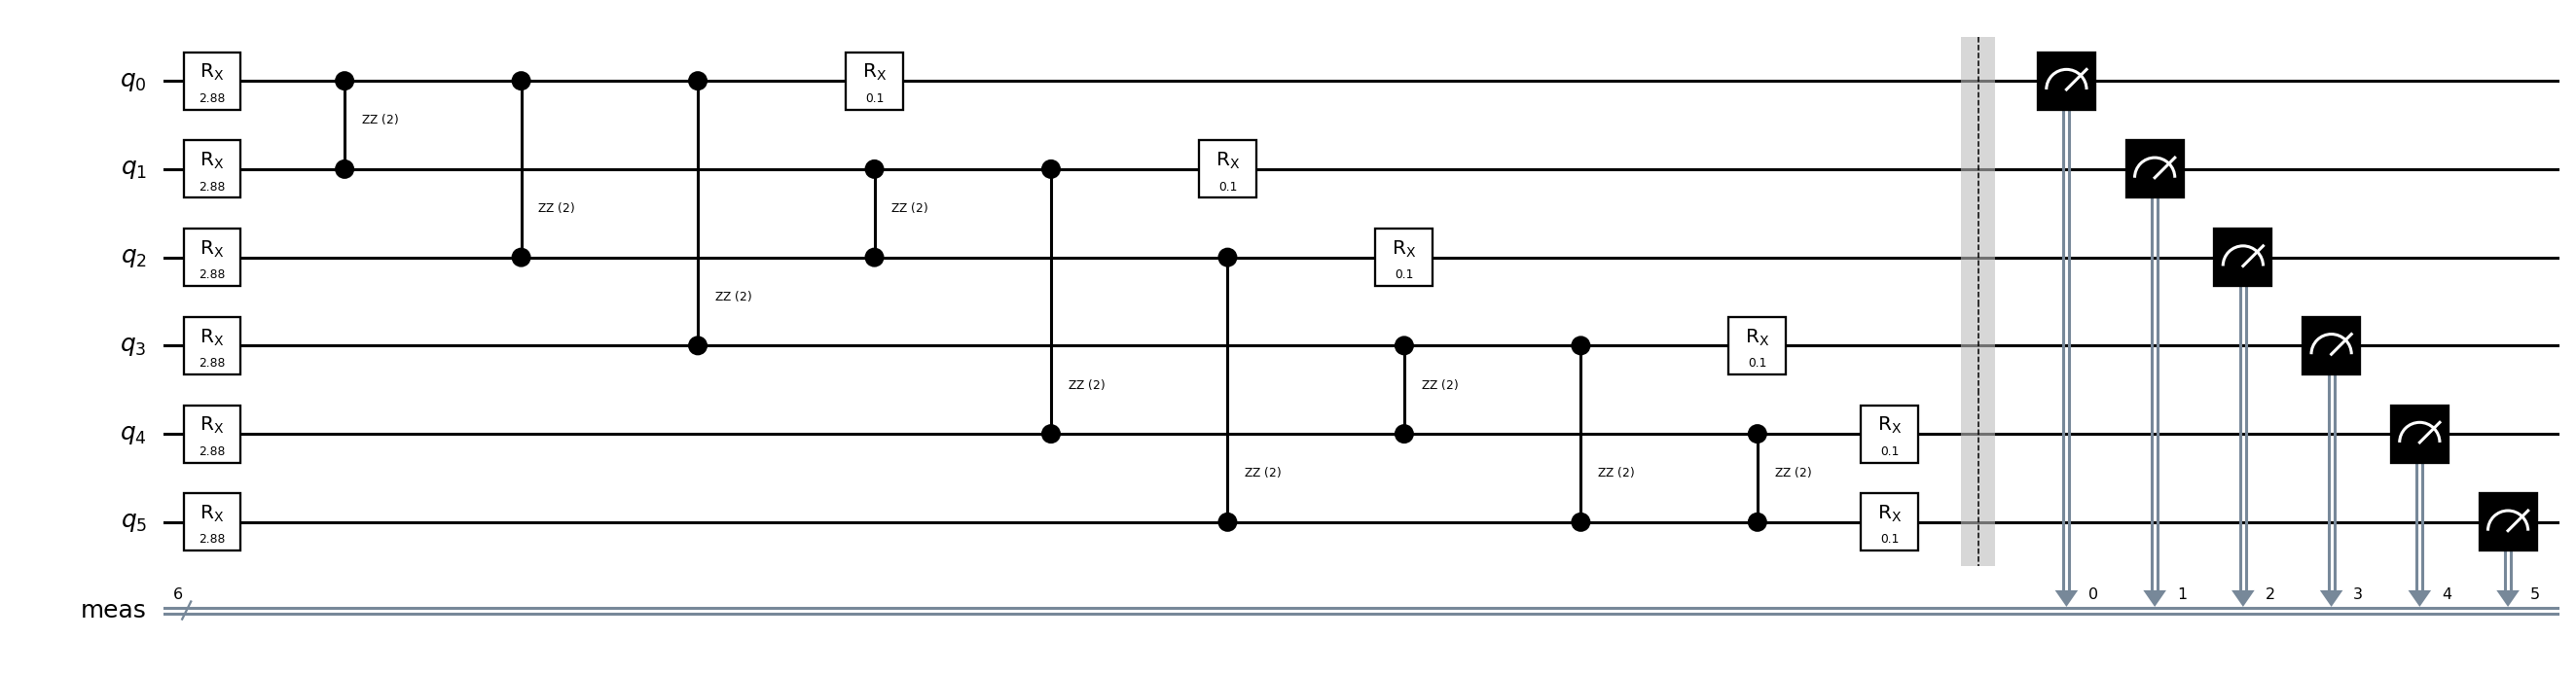

In [2]:
from quic import build_circuit
from quic.datasets import named_graphs

graphs = named_graphs()
prism = graphs["prism"]

qc = build_circuit(nx.to_numpy_array(prism), measure=True)
qc.draw(output="mpl", fold=-1, style="bw")

## Five graphs

Two of these are special: the **triangular prism** and $K_{3,3}$ are the *only*
connected cubic graphs on six vertices — a complete census in miniature. They
share the degree sequence $(3,3,3,3,3,3)$, so the encoder and mixer layers of
their circuits are *identical*; every difference in their distributions comes
from the entangler seeing different edge sets. They differ exactly in cycle
structure: the prism has 2 triangles and 3 four-cycles, $K_{3,3}$ has 0 and 9.
The path and cycle bring degree variation into the encoder, and the small
irregular graph previews the degree-sector structure that notebook 05 turns
into a measurement strategy.


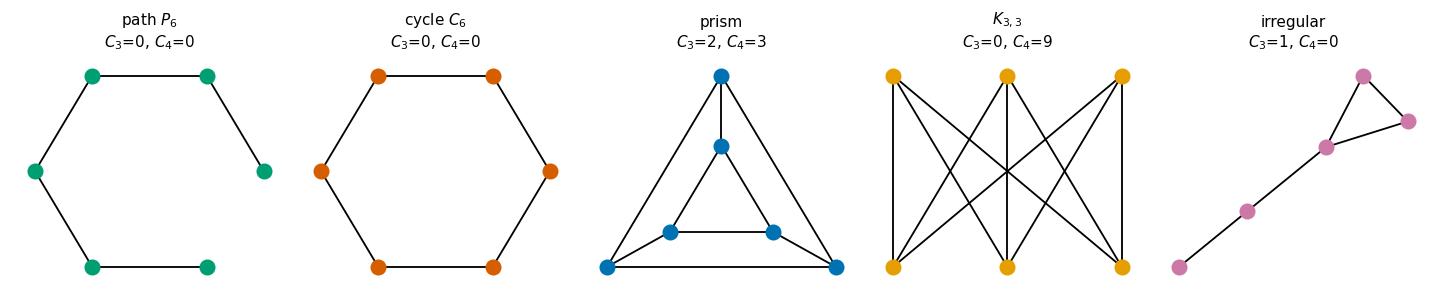

In [3]:
from quic.graph_features import cycle_counts

irregular = nx.Graph([(0, 1), (1, 2), (2, 0), (2, 3), (3, 4)])
DEMO = {"path $P_6$": graphs["path_6"], "cycle $C_6$": graphs["cycle_6"],
        "prism": prism, "$K_{3,3}$": graphs["K33"], "irregular": irregular}
COLOR = dict(zip(DEMO, [OKABE["green"], OKABE["vermillion"], OKABE["blue"],
                        OKABE["orange"], OKABE["purple"]]))

def layout(name, G):
    if name == "prism":       # outer triangle + inner triangle
        outer = {i: 1.0 * np.array([np.cos(a), np.sin(a)])
                 for i, a in enumerate(np.pi / 2 + 2 * np.pi * np.arange(3) / 3)}
        return {**outer, **{i + 3: 0.45 * outer[i] for i in range(3)}}
    if name == "$K_{3,3}$":
        return {i: np.array([i % 3 - 1, 0.6 if i < 3 else -0.6]) for i in range(6)}
    if name == "irregular":
        return nx.spring_layout(G, seed=4)
    return nx.circular_layout(G)

fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
for ax, (name, G) in zip(axes, DEMO.items()):
    cc = cycle_counts(G, max_len=4)
    nx.draw(G, ax=ax, node_size=90, node_color=COLOR[name], width=1.2,
            pos=layout(name, G))
    ax.set_title(f"{name}\n$C_3$={cc[3]}, $C_4$={cc[4]}", fontsize=10)
plt.show()

## From graph to distribution

The exact output distribution $p_G(x) = |\langle x|U_G|0\rangle|^2$ over all
$2^6 = 64$ bitstrings, computed by exact statevector simulation (the package's
pure-NumPy simulator; `quic.selfcheck()` verified it against Qiskit at the
start of this notebook).

The left panel shows the *labeled* distribution for the prism. The right panel
sorts each graph's distribution — the QuIC embedding $p_G^\downarrow$. Two
things to notice. The sorted curves are **layered**: for a cubic graph at
these angles, probabilities organize by how many qubits deviate from the
dominant outcome ("defects"), and the analytic bounds in notebook 02 prove
the first $1 + n + \binom{n}{2}$ sorted coordinates are exactly the
$\le 2$-defect outcomes (dotted boundaries at ranks 1, 7, 22 for $n = 6$).
And the prism and $K_{3,3}$ curves — identical degree sequence, identical
angles, so the encoder and mixer layers agree gate-for-gate — lie almost on
top of each other at full scale, then separate exactly where the theory says
structure lives: in the deep two-defect ranks and beyond (inset; relative
differences reach $\sim 8\%$ inside the two-defect layer and exceed $100\%$
after it). The weak mixer makes the structural signal *small but exact* —
which is why the rest of the series is careful about nulls, probes, and shot
budgets.


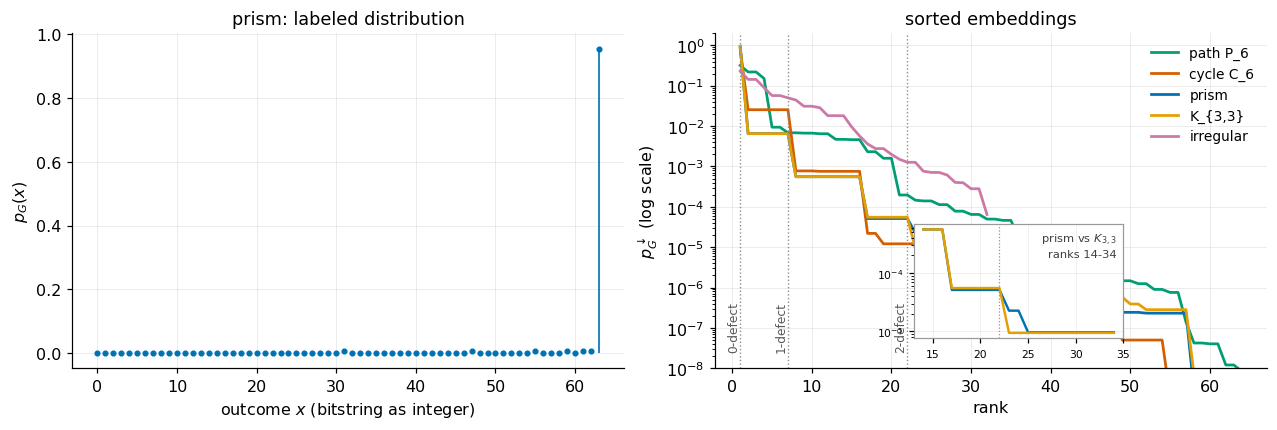

In [4]:
from quic import circuit_probabilities
from quic.readouts import readout_R0

p_labeled = {name: circuit_probabilities(nx.to_numpy_array(G)) for name, G in DEMO.items()}
p_sorted = {name: readout_R0(p) for name, p in p_labeled.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8))

markerline, stemlines, _ = ax1.stem(np.arange(64), p_labeled["prism"], basefmt=" ")
plt.setp(stemlines, color=OKABE["blue"], linewidth=1.1)
plt.setp(markerline, color=OKABE["blue"], markersize=3)
ax1.set_xlabel("outcome $x$ (bitstring as integer)")
ax1.set_ylabel("$p_G(x)$")
ax1.set_title("prism: labeled distribution")

for name in DEMO:
    ranks = np.arange(1, len(p_sorted[name]) + 1)
    ax2.semilogy(ranks, p_sorted[name], linewidth=1.8,
                 color=COLOR[name], label=name.replace("$", ""))
ax2.set_ylim(1e-8, 2)
for boundary, label in [(1, "0-defect"), (7, "1-defect"), (22, "2-defect")]:
    ax2.axvline(boundary, color="0.55", linewidth=0.9, linestyle=":")
    ax2.annotate(label, (boundary, 2.5e-8), rotation=90, fontsize=8,
                 color="0.35", ha="right", va="bottom")
ax2.set_xlabel("rank")
ax2.set_ylabel("$p_G^{\\downarrow}$ (log scale)")
ax2.set_title("sorted embeddings")
ax2.legend(frameon=False, fontsize=9, loc="upper right")

inset = ax2.inset_axes([0.36, 0.09, 0.38, 0.34])
inset.set_facecolor("white")
zoom = slice(13, 34)
ranks = np.arange(1, 65)
for name in ("prism", "$K_{3,3}$"):
    inset.semilogy(ranks[zoom], p_sorted[name][zoom], linewidth=1.6,
                   color=COLOR[name])
inset.axvline(22, color="0.55", linewidth=0.8, linestyle=":")
inset.text(0.97, 0.93, "prism vs $K_{3,3}$\nranks 14-34", transform=inset.transAxes,
           fontsize=7.5, ha="right", va="top", color="0.25")
inset.tick_params(labelsize=7)
inset.grid(alpha=0.2)
for spine in inset.spines.values():
    spine.set_visible(True); spine.set_color("0.6")
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/feature_map.png")
plt.show()

## Sorting is the invariance

Relabeling the vertices of $G$ permutes the qubits, which permutes the outcome
bitstrings: the *labeled* distribution scrambles completely. Sorting forgets
the labels, so the sorted vector is a **graph invariant** — isomorphic graphs
receive identical embeddings, exactly.

The check below is end-to-end: it relabels the prism, rebuilds the circuit
from the relabeled adjacency matrix, re-simulates, and compares. (Sorting is
also 1-Lipschitz in every $\ell_p$ norm, so perturbation bounds on
probabilities survive it — notebook 02, section 8.)


In [5]:
rng = np.random.default_rng(0)
perm = rng.permutation(6)
A = nx.to_numpy_array(prism)
A_relabeled = A[np.ix_(np.argsort(perm), np.argsort(perm))]
p_relabeled = circuit_probabilities(A_relabeled)

labeled_change = np.max(np.abs(p_labeled["prism"] - p_relabeled))
sorted_change = np.max(np.abs(p_sorted["prism"] - readout_R0(p_relabeled)))
assert sorted_change < 1e-14

print(f"vertex relabeling: {perm}")
print(f"labeled distribution moves by   max |dp| = {labeled_change:.3e}")
print(f"sorted embedding moves by       max |dp| = {sorted_change:.3e}")

vertex relabeling: [3 2 5 4 0 1]
labeled distribution moves by   max |dp| = 5.065e-04
sorted embedding moves by       max |dp| = 4.337e-18


## Embedding geometry, and the honest yardstick

Pairwise $\ell_1$ distances between the five embeddings (the 5-vertex
graph's embedding is zero-padded to the common length; a sorted distribution
has zero mass beyond its own $2^n$ outcomes). The number to
calibrate every later claim against is the **isomorphism null**: the distance
between a graph and a relabeled copy of itself, which measures pure numerical
noise. Structural separations here are $10^{12}$–$10^{14}$ times that null —
when notebook 04 claims two *cospectral* graphs get different embeddings, it
is this comparison, not a floating-point accident.


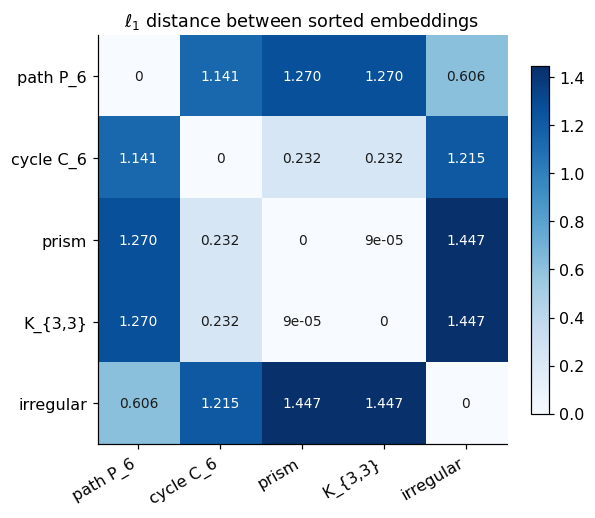

prism vs K33 (cubic census at n=6):  L1 = 0.0001
prism vs relabeled prism (the null): L1 = 5.713e-18


In [6]:
names = list(DEMO)

def padded(name, length=64):
    # zero-pad: a sorted distribution has zero mass beyond its own 2^n outcomes
    vec = np.zeros(length)
    vec[:len(p_sorted[name])] = p_sorted[name]
    return vec

distance = np.zeros((5, 5))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        distance[i, j] = np.abs(padded(a) - padded(b)).sum()

null = np.abs(p_sorted["prism"] - readout_R0(p_relabeled)).sum()

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(distance, cmap="Blues")
ax.set_xticks(range(5), [n.replace("$", "") for n in names], rotation=30, ha="right")
ax.set_yticks(range(5), [n.replace("$", "") for n in names])
for i in range(5):
    for j in range(5):
        v = distance[i, j]
        label = "0" if v == 0 else (f"{v:.3f}" if v >= 0.005 else f"{v:.0e}")
        ax.text(j, i, label, ha="center", va="center", fontsize=9,
                color="white" if v > 0.6 * distance.max() else "#1a1a1a")
ax.set_title("$\\ell_1$ distance between sorted embeddings")
ax.grid(False)
fig.colorbar(im, shrink=0.85)
plt.show()

print(f"prism vs K33 (cubic census at n=6):  L1 = {distance[2, 3]:.4f}")
print(f"prism vs relabeled prism (the null): L1 = {null:.3e}")

## Where this goes

The prism–$K_{3,3}$ separation is one pair at $n = 6$. The rest of the series
scales the question up and makes it precise: notebook 02 derives *what* the
circuit encodes (the entangler is a boundary transform of an
imaginary-coupling Ising model, and the second purity derivative closes
exactly on triangles, four-cycles, and diamonds); notebook 03 measures *what
organizes* the embedding across the complete 509-graph cubic census at
$n = 14$; notebook 04 shows the embedding is *not a function of the adjacency
spectrum*, on exactly-cospectral witness pairs; and notebook 05 asks what a
finite shot budget leaves, where the choice of readout — global sort,
Hamming-weight pooling, or degree-sector pooling — turns out to matter more
than the budget itself.
